# LSH Families: SimHash and p-Stable Projections

## Learning Objectives

By the end of this notebook you will be able to:
- Define cosine similarity and angular distance, and explain when they are the right choice over Jaccard
- Implement SimHash (random-hyperplane hashing) and verify the collision-probability formula empirically
- Explain p-stable projections for Euclidean distance and implement the bucketing scheme
- Choose the bucket width `w` for Euclidean LSH given a distance threshold
- Select the appropriate hash family for a given data type and distance measure

## Cosine Similarity and Angular Distance

**Cosine similarity** measures the angle between two vectors:

$$\text{cos}(\mathbf{u}, \mathbf{v}) = \frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{u}\| \|\mathbf{v}\|}$$

It is 1 when the vectors point in the same direction, 0 when perpendicular, and −1 when opposite. It ignores magnitude — two documents with the same word-frequency ratios but different lengths are considered identical.

**Angular distance** converts this to a proper distance in [0, 1]:

$$D_{\text{ang}}(\mathbf{u}, \mathbf{v}) = \frac{\theta(\mathbf{u}, \mathbf{v})}{\pi} \in [0, 1]$$

where θ is the angle between the vectors in radians, θ = arccos(cos sim).

**When to use cosine / angular distance instead of Jaccard:**
- TF-IDF vectors (each document is a sparse non-binary vector of term weights)
- Word or sentence embeddings from neural language models
- Neural network activation vectors
- Any continuous vector representation where direction matters more than overlap

**Why not Jaccard here?** Jaccard requires sets (or binary vectors). A document represented as TF-IDF has real-valued feature weights, not a set membership indicator. You *could* binarize it, but that loses the weight information. Cosine similarity uses the full weight vector.

## Random Hyperplane Hash (SimHash)

**Hash construction.** Choose a random unit vector **r** ~ Uniform(Sᵈ⁻¹) (equivalently, draw each component i.i.d. from N(0,1) and normalize). Define:

$$h_{\mathbf{r}}(\mathbf{v}) = \text{sign}(\mathbf{r} \cdot \mathbf{v}) \in \{+1, -1\}$$

The hyperplane {**x** : **r**·**x** = 0} divides space into two half-spaces. **h_r(u) = h_r(v)** iff **u** and **v** lie in the same half-space.

**Key theorem (Charikar 2002):**

$$P[h_{\mathbf{r}}(\mathbf{u}) = h_{\mathbf{r}}(\mathbf{v})] = 1 - \frac{\theta(\mathbf{u}, \mathbf{v})}{\pi}$$

**Proof sketch.** The hyperplane separates **u** and **v** iff **r** lies in the "wedge" between the two orthogonal complements. The probability of landing in this wedge is proportional to the dihedral angle, which equals θ/π.

**As a sensitive family.** SimHash is **(θ₁, θ₂, 1−θ₁/π, 1−θ₂/π)-sensitive** for angular distance.

For vectors with angular distance ≤ θ₁ (very similar direction): P[collision] ≥ 1 − θ₁/π (close to 1).
For vectors with angular distance ≥ θ₂ (different direction): P[collision] ≤ 1 − θ₂/π (smaller).

**Note.** The collision probability is a linear function of θ/π, which is a gentler slope than MinHash's J. This means SimHash needs more hashes for equivalent discrimination — but it correctly handles continuous-valued vectors.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# -------------------------------------------------------------------
# SimHash implementation
# -------------------------------------------------------------------

def simhash_signatures(vectors, n_hashes, rng=None):
    """
    Compute SimHash signatures for a matrix of row-vectors.

    Parameters
    ----------
    vectors   : (n, d) array of float  -  each row is one document/item
    n_hashes  : number of random hyperplanes k
    rng       : numpy random Generator (for reproducibility)

    Returns
    -------
    signatures : (n, n_hashes) array of int8 values in {+1, -1}
    """
    if rng is None:
        rng = np.random.default_rng(42)
    n, d = vectors.shape
    # draw k random direction vectors from N(0, I_d)
    # shape: (d, n_hashes)
    directions = rng.standard_normal((d, n_hashes))
    # project each vector onto each direction: (n, n_hashes)
    projections = vectors @ directions
    # sign: +1 if positive, -1 if non-positive
    return np.sign(projections).astype(np.int8)

def simhash_collision_rate(sigs_u, sigs_v):
    """
    Fraction of hash functions for which h(u) == h(v).
    sigs_u, sigs_v : 1-D arrays of {+1,-1}, same length.
    """
    return np.mean(sigs_u == sigs_v)

# -------------------------------------------------------------------
# Demo: small handcrafted word vectors (5-dimensional)
# -------------------------------------------------------------------
# vocabulary: [king, queen, man, woman, royal]
word_vectors = np.array([
    [1.0,  0.2,  0.9,  0.1,  0.8],  # king
    [0.2,  1.0,  0.1,  0.9,  0.8],  # queen
    [0.8,  0.1,  1.0,  0.0,  0.1],  # man
    [0.1,  0.8,  0.0,  1.0,  0.1],  # woman
    [0.9,  0.8,  0.2,  0.2,  1.0],  # royal
], dtype=float)
words = ["king", "queen", "man", "woman", "royal"]

# normalize to unit vectors so cosine_similarity = dot product
norms = np.linalg.norm(word_vectors, axis=1, keepdims=True)
word_vectors_normed = word_vectors / norms

# exact cosine similarities
cos_sim_matrix = word_vectors_normed @ word_vectors_normed.T
print("Exact cosine similarities:")
header = f"{'':8s}" + "".join(f"{w:>8s}" for w in words)
print(header)
for i, w in enumerate(words):
    row = f"{w:<8s}" + "".join(f"{cos_sim_matrix[i,j]:>8.3f}" for j in range(len(words)))
    print(row)

# SimHash signatures
rng = np.random.default_rng(0)
k = 500
sigs = simhash_signatures(word_vectors_normed, n_hashes=k, rng=rng)

print("\nSimHash estimated collision rates (k=500):")
print(header)
for i, w in enumerate(words):
    rates = [simhash_collision_rate(sigs[i], sigs[j]) for j in range(len(words))]
    row = f"{w:<8s}" + "".join(f"{r:>8.3f}" for r in rates)
    print(row)

# theoretical prediction: P = 1 - arccos(cos_sim)/pi
print("\nTheoretical prediction P = 1 - arccos(cos_sim)/π:")
print(header)
for i, w in enumerate(words):
    preds = [1 - np.arccos(np.clip(cos_sim_matrix[i,j], -1, 1)) / np.pi for j in range(len(words))]
    row = f"{w:<8s}" + "".join(f"{p:>8.3f}" for p in preds)
    print(row)


Exact cosine similarities:
            king   queen     man   woman   royal
king       1.000   0.488   0.884   0.216   0.819
queen      0.488   1.000   0.216   0.884   0.787
man        0.884   0.216   1.000   0.102   0.537
woman      0.216   0.884   0.102   1.000   0.503
royal      0.819   0.787   0.537   0.503   1.000

SimHash estimated collision rates (k=500):
            king   queen     man   woman   royal
king       1.000   0.664   0.836   0.568   0.812
queen      0.664   1.000   0.556   0.856   0.792
man        0.836   0.556   1.000   0.516   0.664
woman      0.568   0.856   0.516   1.000   0.668
royal      0.812   0.792   0.664   0.668   1.000

Theoretical prediction P = 1 - arccos(cos_sim)/π:
            king   queen     man   woman   royal
king       1.000   0.662   0.845   0.569   0.806
queen      0.662   1.000   0.569   0.845   0.789
man        0.845   0.569   1.000   0.533   0.680
woman      0.569   0.845   0.533   1.000   0.668
royal      0.806   0.789   0.680   0.668   1.

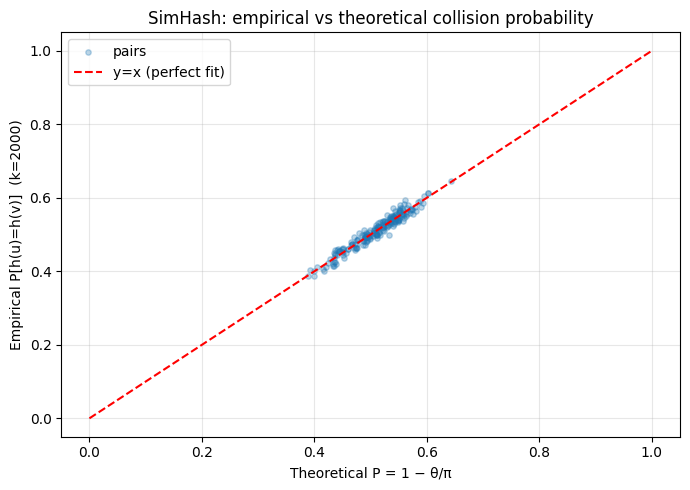

Max absolute error: 0.0341
Mean absolute error: 0.0094
Correlation: 0.972315


In [2]:
# -------------------------------------------------------------------
# Empirical verification: P[h(u)=h(v)] vs 1 - theta/pi
# -------------------------------------------------------------------

rng = np.random.default_rng(1)
d = 50       # dimension
k = 2000     # many hashes for accurate estimate
n_pairs = 200

# generate random pairs of unit vectors
u_mat = rng.standard_normal((n_pairs, d))
v_mat = rng.standard_normal((n_pairs, d))
u_mat /= np.linalg.norm(u_mat, axis=1, keepdims=True)
v_mat /= np.linalg.norm(v_mat, axis=1, keepdims=True)

# compute exact angles
cos_sims = np.einsum('ij,ij->i', u_mat, v_mat)
angles = np.arccos(np.clip(cos_sims, -1, 1))

# compute SimHash collision rates
directions = rng.standard_normal((d, k))
proj_u = u_mat @ directions   # (n_pairs, k)
proj_v = v_mat @ directions
sign_u = np.sign(proj_u)
sign_v = np.sign(proj_v)
empirical_rate = np.mean(sign_u == sign_v, axis=1)
theoretical_rate = 1 - angles / np.pi

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(theoretical_rate, empirical_rate, alpha=0.3, s=15, label="pairs")
ax.plot([0, 1], [0, 1], 'r--', label="y=x (perfect fit)")
ax.set_xlabel("Theoretical P = 1 − θ/π")
ax.set_ylabel("Empirical P[h(u)=h(v)]  (k=2000)")
ax.set_title("SimHash: empirical vs theoretical collision probability")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("simhash_verification.png", dpi=100)
plt.show()

# quantify fit
residuals = empirical_rate - theoretical_rate
print(f"Max absolute error: {np.max(np.abs(residuals)):.4f}")
print(f"Mean absolute error: {np.mean(np.abs(residuals)):.4f}")
print(f"Correlation: {np.corrcoef(theoretical_rate, empirical_rate)[0,1]:.6f}")


## SimHash as a Sensitive Family (AND+OR Amplification)

Since SimHash is (θ₁, θ₂, 1−θ₁/π, 1−θ₂/π)-sensitive, define:

$$p_1 = 1 - \frac{\theta_1}{\pi}, \quad p_2 = 1 - \frac{\theta_2}{\pi}$$

The AND+OR amplification works identically to MinHash:

$$P[\text{candidate}] = 1 - \left(1 - p^r\right)^b \quad \text{where } p = 1 - \theta/\pi$$

**Choosing parameters.** Suppose you want to find all pairs with angular distance ≤ 20° (θ₁ = π/9) while suppressing pairs with θ ≥ 60° (θ₂ = π/3):

- p₁ = 1 − (1/9) ≈ 0.889
- p₂ = 1 − (1/3) ≈ 0.667

Use the same (b, r) sweep as in the theory notebook to find the right configuration.

**Comparison with MinHash.** MinHash has P = J (Jaccard similarity); SimHash has P = 1 − θ/π (angular proximity). For a given pair of thresholds, SimHash's base probabilities tend to be closer together (the angular function is less "extreme" than Jaccard at extreme values), so SimHash often requires more bands for equivalent precision.

**When SimHash wins.** Data is naturally described by direction in a vector space (embeddings, TF-IDF, principal component scores). Jaccard/MinHash would require discretization and loses information.

## Euclidean Distance and p-Stable Projections

For points **u**, **v** ∈ ℝᵈ, distance is ‖**u** − **v**‖₂. Unlike Jaccard or cosine, there is no single "natural" probability from one hash evaluation — the collision probability must be designed by choosing a **bucket width** w.

**Hash construction.** Draw **r** ~ N(**0**, **I**_d) and b ~ Uniform[0, w]. Define:

$$h_{\mathbf{r},b,w}(\mathbf{v}) = \left\lfloor \frac{\mathbf{r} \cdot \mathbf{v} + b}{w} \right\rfloor$$

Two points land in the same bucket iff their 1-D projections (shifted by b) fall within the same width-w interval.

**Why normal distribution?** The Gaussian is 2-stable: if **r** ~ N(**0**, **I**), then **r**·(**u**−**v**) ~ N(0, ‖**u**−**v**‖²). So the projection gap depends only on ‖**u**−**v**‖, not on direction — the hash is isotropic.

**Collision probability.** Let c = ‖**u** − **v**‖. The collision probability is:

$$P[h(\mathbf{u}) = h(\mathbf{v})] = \int_0^w \frac{1}{c} f\!\left(\frac{t}{c}\right) \left(1 - \frac{t}{w}\right) dt$$

where f is the standard normal density. Approximately:

$$P \approx 1 - 2\Phi\!\left(-\frac{w}{c}\right) - \frac{2}{\sqrt{2\pi}} \cdot \frac{c}{w} \cdot \left(1 - e^{-w^2/(2c^2)}\right)$$

where Φ is the standard normal CDF. As w → ∞, P → 1; as w → 0, P → 0; and P decreases as c increases.

w=4.0, k=5 projections
  Within-cluster collision rate:  0.986
  Across-cluster collision rate:  0.407


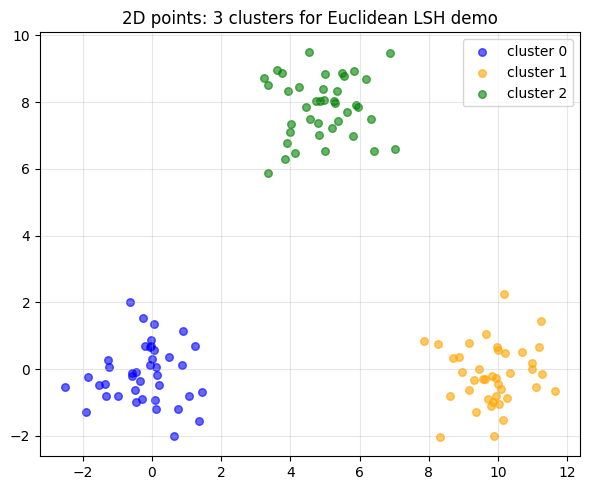

In [3]:
from scipy.stats import norm as scipy_norm
from scipy.integrate import quad

# -------------------------------------------------------------------
# p-Stable (Euclidean) LSH implementation
# -------------------------------------------------------------------

def euclidean_lsh_signatures(points, n_hashes, w, rng=None):
    """
    Compute Euclidean LSH signatures for a matrix of points.

    Parameters
    ----------
    points    : (n, d) array
    n_hashes  : number of projections k
    w         : bucket width

    Returns
    -------
    signatures : (n, n_hashes) int array (bucket indices)
    """
    if rng is None:
        rng = np.random.default_rng(42)
    n, d = points.shape
    # random Gaussian directions: (d, n_hashes)
    directions = rng.standard_normal((d, n_hashes))
    # random offsets: (n_hashes,)
    offsets = rng.uniform(0, w, size=n_hashes)
    # project + shift + floor
    projections = points @ directions + offsets   # (n, n_hashes)
    return np.floor(projections / w).astype(np.int32)

def euclidean_collision_prob_exact(c, w, n_samples=10000):
    """Estimate P[same bucket] by numerical integration for distance c, width w."""
    def integrand(t):
        return (1.0 / c) * scipy_norm.pdf(t / c) * (1 - t / w)
    result, _ = quad(integrand, 0, w)
    return result

def euclidean_collision_prob_approx(c, w):
    """Closed-form approximation."""
    ""
    ratio = w / c
    phi_term = 1 - 2 * scipy_norm.cdf(-ratio)
    exp_term = (2 / np.sqrt(2 * np.pi)) * (1 / ratio) * (1 - np.exp(-ratio**2 / 2))
    return phi_term - exp_term

# -------------------------------------------------------------------
# Demo: 2D points in 3 clusters
# -------------------------------------------------------------------
rng = np.random.default_rng(7)
n_per_cluster = 40
centers = np.array([[0, 0], [10, 0], [5, 8]], dtype=float)
cluster_labels = np.repeat([0, 1, 2], n_per_cluster)
points = np.vstack([
    rng.normal(loc=c, scale=1.0, size=(n_per_cluster, 2))
    for c in centers
])

# Compute signatures with w=4
w = 4.0
k_proj = 5
sigs = euclidean_lsh_signatures(points, n_hashes=k_proj, w=w, rng=rng)

# Count matches: two points match if they share at least one bucket
n = len(points)
same_cluster = cluster_labels[:, None] == cluster_labels[None, :]
matched = np.zeros((n, n), dtype=bool)
for col in range(k_proj):
    matched |= (sigs[:, col:col+1] == sigs[:, col].T.reshape(1, -1))

# within-cluster and across-cluster collision rates
within_rate  = matched[same_cluster & ~np.eye(n, dtype=bool)].mean()
across_rate  = matched[~same_cluster].mean()
print(f"w={w}, k={k_proj} projections")
print(f"  Within-cluster collision rate:  {within_rate:.3f}")
print(f"  Across-cluster collision rate:  {across_rate:.3f}")

# Visualise the clusters
fig, ax = plt.subplots(figsize=(6, 5))
for c_idx, color in enumerate(['blue', 'orange', 'green']):
    mask = cluster_labels == c_idx
    ax.scatter(points[mask, 0], points[mask, 1],
               c=color, alpha=0.6, s=30, label=f"cluster {c_idx}")
ax.set_title("2D points: 3 clusters for Euclidean LSH demo")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("euclidean_lsh_clusters.png", dpi=100)
plt.show()


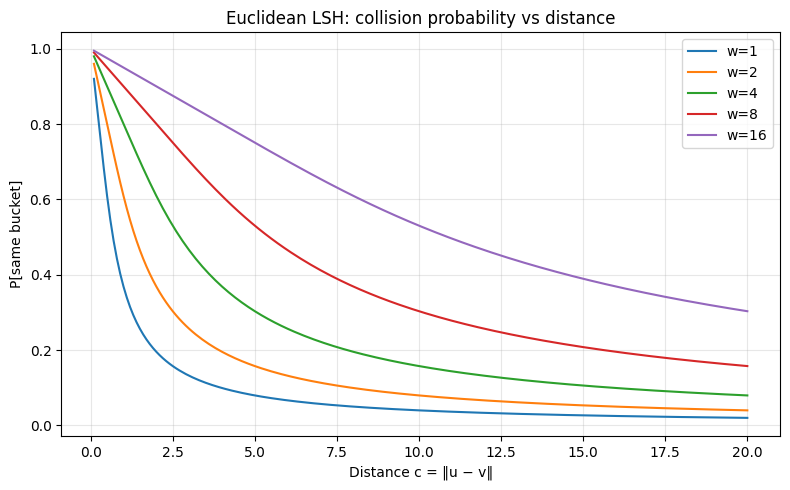

Approximation vs exact integration (w=4):
       c     approx      exact      error
     1.0     0.8005     0.4003   0.400266
     2.0     0.6095     0.3048   0.304774
     4.0     0.3687     0.1844   0.184373
     6.0     0.2565     0.1283   0.128266
     8.0     0.1954     0.0977   0.097709
    12.0     0.1318     0.0659   0.065882
    16.0     0.0992     0.0496   0.049610


In [4]:
# -------------------------------------------------------------------
# Collision probability vs distance for different w values
# -------------------------------------------------------------------

c_vals = np.linspace(0.1, 20, 200)
w_vals = [1, 2, 4, 8, 16]

fig, ax = plt.subplots(figsize=(8, 5))
for w in w_vals:
    probs = [euclidean_collision_prob_approx(c, w) for c in c_vals]
    ax.plot(c_vals, probs, label=f"w={w}")

ax.set_xlabel("Distance c = ‖u − v‖")
ax.set_ylabel("P[same bucket]")
ax.set_title("Euclidean LSH: collision probability vs distance")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("euclidean_collision_prob.png", dpi=100)
plt.show()

# Show that approx matches exact
print("Approximation vs exact integration (w=4):")
print(f"{'c':>8} {'approx':>10} {'exact':>10} {'error':>10}")
for c in [1, 2, 4, 6, 8, 12, 16]:
    approx = euclidean_collision_prob_approx(c, w=4)
    exact  = euclidean_collision_prob_exact(c, w=4)
    print(f"{c:>8.1f} {approx:>10.4f} {exact:>10.4f} {abs(approx-exact):>10.6f}")


## Choosing w for Euclidean LSH

The bucket width w controls the trade-off between sensitivity and specificity:

- **w too small**: very few pairs land in the same bucket → high FNR, but very low FPR.
- **w too large**: almost every pair is in the same bucket → low FNR, but useless (high FPR).

**Rule of thumb.** Set w such that P[collision] ≈ 0.9 for pairs at your "close" distance threshold c₁, and P[collision] ≈ 0.1 for pairs at your "far" threshold c₂. Then use AND+OR to further amplify.

In practice, w is often chosen by:
1. Computing the median pairwise distance in a sample from your dataset.
2. Setting w ≈ median / 2 to get P ≈ 0.5 at the median, giving a good starting point for tuning.


In [5]:
# -------------------------------------------------------------------
# Choosing w: find w such that P(c1) ~ p_target_close, P(c2) ~ p_target_far
# -------------------------------------------------------------------

from scipy.optimize import brentq

def find_w_for_target(c1, p_target):
    """Find w such that P_approx(c1, w) = p_target."""
    ""
    # P is increasing in w for fixed c, so brentq works
    f = lambda w: euclidean_collision_prob_approx(c1, w) - p_target
    # search in [0.01, 1000 * c1]
    try:
        return brentq(f, 0.01, 1000 * c1)
    except ValueError:
        return None

# Target: c1=2 (close), c2=8 (far), p1=0.8, p2=0.2
c1, c2 = 2.0, 8.0
p1_target = 0.8

w_opt = find_w_for_target(c1, p1_target)
if w_opt:
    p2_actual = euclidean_collision_prob_approx(c2, w_opt)
    print(f"Target: P(c={c1}) = {p1_target}")
    print(f"Optimal w = {w_opt:.3f}")
    print(f"Resulting P(c={c2}) = {p2_actual:.4f}")
    print(f"Base family: ({c1}, {c2}, {p1_target}, {p2_actual:.3f})-sensitive")

# Sweep: show how w choice affects both probabilities
print("\nEffect of w on P(c1=2) and P(c2=8):")
print(f"{'w':>8} {'P(c=2)':>10} {'P(c=8)':>10} {'gap':>10}")
for w in [0.5, 1, 2, 4, 6, 8, 12, 20]:
    p_close = euclidean_collision_prob_approx(c1, w)
    p_far   = euclidean_collision_prob_approx(c2, w)
    marker = " <-- good" if 0.6 < p_close < 0.95 and p_far < 0.4 else ""
    print(f"{w:>8.1f} {p_close:>10.4f} {p_far:>10.4f} {p_close-p_far:>10.4f}{marker}")


Target: P(c=2.0) = 0.8
Optimal w = 7.979
Resulting P(c=8.0) = 0.3679
Base family: (2.0, 8.0, 0.8, 0.368)-sensitive

Effect of w on P(c1=2) and P(c2=8):
       w     P(c=2)     P(c=8)        gap
     0.5     0.0992     0.0249     0.0743
     1.0     0.1954     0.0498     0.1456
     2.0     0.3687     0.0992     0.2695
     4.0     0.6095     0.1954     0.4141 <-- good
     6.0     0.7343     0.2859     0.4484 <-- good
     8.0     0.8005     0.3687     0.4318 <-- good
    12.0     0.8670     0.5072     0.3599
    20.0     0.9202     0.6824     0.2378


## Comparison: Which LSH Family to Use?

| Data Type | Similarity Measure | LSH Family | Hash Function | Collision Probability |
|---|---|---|---|---|
| Sets, binary vectors | Jaccard similarity | MinHash | Random permutation (or linear hash mod p) | P = J(A,B) |
| Real-valued vectors (embeddings, TF-IDF) | Cosine similarity | SimHash (random hyperplane) | sign(**r**·**v**), **r** ~ N(**0**, **I**) | P = 1 − θ/π |
| Bit strings | Hamming distance | Random bit selection | h_i(**x**) = **x**[i] | P = 1 − d/L |
| Points in ℝᵈ (coordinates) | Euclidean distance | p-stable projections | ⌊(**r**·**v** + b)/w⌋, **r** ~ N(**0**, **I**) | Depends on w/c |
| Strings with edits | Edit distance | Sketch functions | Based on q-grams + random projections | Complex — not covered here |

**Decision guide:**
1. Is your data a **set** (or can it be easily represented as one)? → MinHash
2. Is your data a **vector** and direction matters (angle, not magnitude)? → SimHash
3. Is your data a **vector** and actual distances matter? → p-stable
4. Do you have **short strings** with typos? → Character 2-3 shingles + MinHash is often good enough
5. Do you need **edit distance** exactly? → q-gram sketches (not covered; see Andoni & Indyk 2008)

The AND+OR amplification framework from `ml_002_04_lsh_theory.ipynb` applies to all of these — once you know (p₁, p₂) for your chosen family, tune (b, r) the same way.